# "Tabular Classification"
> "The train and test datasets contain parameters of different types of sponges. Because of there being no overlap in types of sponges between the training and testing data, we must use the training data to build an intuition about the unseen products in the testing data."

- toc: false
- branch: master
- badges: true
- comments: true
- categories: [fastpages, jupyter]
- image: images/some_folder/your_image.png
- hide: false
- search_exclude: true
- metadata_key1: metadata_value1
- metadata_key2: metadata_value2a

In [2]:
#hide
import numpy as np
import pandas as pd
from pandas_profiling import ProfileReport
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import GroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier
from pycaret.classification import *
from xgboost import plot_importance
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

In [249]:
#hide
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_df.pop('product_code')
train_df.pop('attribute_0')
train_df.pop('attribute_1')
train_df.pop('attribute_2')
train_df.pop('attribute_3')
#train_df = pd.get_dummies(train_df)

test_df.pop('product_code')
test_df.pop('attribute_0')
test_df.pop('attribute_1')
test_df.pop('attribute_2')
test_df.pop('attribute_3')
#test_df = pd.get_dummies(test_df)


train_df, val_df = train_test_split(train_df, random_state=1)

y_train = train_df.pop('failure')
y_val = val_df.pop('failure')



Let us do a z-test to determine the p-value for features with missing values having a significantly different failure rate than the mean failure rate.

In [251]:
#collapse
z = {}
xbar = np.average(y_train) # Average failure rate for all samples

for col in train_df:
    if train_df[col].isna().sum() > 0:
        mask = (train_df[col].isna()) & (y_train.values ==1) 
        fail = mask.sum()
        total = train_df[col].isna().sum()
        z[col] = (fail - xbar*total) / np.sqrt(total*xbar*(1-xbar))
z = {k: v for k, v in sorted(z.items(), key=lambda item: item[1])}
print(z) 

{'measurement_3': -2.3081239192358893, 'measurement_7': -0.6168090614020341, 'loading': -0.5884139027237291, 'measurement_8': -0.2608394720852192, 'measurement_6': -0.2487830493916941, 'measurement_10': -0.23930183936832636, 'measurement_13': -0.232157095534432, 'measurement_11': 0.010588023134326956, 'measurement_14': 0.02636051305111207, 'measurement_16': 0.12573203265182414, 'measurement_17': 0.19615458574582673, 'measurement_15': 0.4239675552974366, 'measurement_12': 0.9470533855070152, 'measurement_9': 1.5441310229399012, 'measurement_4': 1.8461213130860923, 'measurement_5': 2.408654616260529}


Our sample consists of all items with missing value, and out of that sample, we want to see what percent fail. If that percent is more or less than 1.96 standard deviations from the population failure rate, we say that the measurement being missing is statistically significant in predicting the failure of the part. In this case, a z score of +-1.96 occurs for features measurement_3 and measurement_5. We then can create new features that take on boolean values of whether measurement 3 and 5 are missing.

In [6]:
#hide
def train(train,val,y_train,y_val,param,num_round,doVal=True,sklearn=False):
    dtrain = xgb.DMatrix(train, y_train, enable_categorical=True)
    if doVal:
        dval = xgb.DMatrix(val,y_val, enable_categorical=True)

    if sklearn:
        bst = make_pipeline(StandardScaler(), LogisticRegression())
        bst = bst.fit(train,y_train)
    else:
        bst = xgb.train(param, dtrain, num_round)
    
    if doVal:
        if sklearn:
            val_preds = bst.predict(val)
        else:
            val_preds = bst.predict(dval)
        val_preds = val_preds >= 0.5
        accuracy = np.round(sum(val_preds==y_val)/len(val_preds),4)*100
        #print(accuracy)
        return bst, accuracy
    else:
        return bst

#bst, accuracy = train(train_df,val_df,y_train,y_val)
#print(accuracy)

In [79]:
#hide
def predict(test,bst,to_file=False,ids=None,sklearn=True,threshold=0.5):
    if sklearn:
        preds = bst.predict(test)
    else:
        dtest = xgb.DMatrix(test, enable_categorical=True)
        preds = bst.predict(dtest)

    
    if to_file:
        p = preds >= threshold
        print(preds[:5])
        print(max(preds),np.mean(preds))
        sub = pd.DataFrame({'id':ids, 'failure':p.astype(int)})
        sub.to_csv('submission.csv', index=False)  
    return preds

So now we have established a baseline accuracy with all problematic columns removed and no preprocessing. What if we do some work? First let us ask ourselves how we should evaluate our model. Is accuracy enough or can we get better instead from AUROC/AUPRC? If so, which to choose? Let's first evaulate the distribution of classes

In [7]:
percentFailTrain = sum(y_train)/len(y_train)
print('Train Fail Percent: ' + str(percentFailTrain*100))
percentFailTrain = sum(y_val)/len(y_val)
print('Val Fail Percent: ' + str(percentFailTrain*100))

Train: 0.21317810006523813
Val: 0.21089869035074515


We can see that there is approximately a 4:1 distribution of classes in the dataset, which is unbalanced enough to warrant the use the PR curve, since the AUROC is biased when used for unbalanced datasets. Let's first process our raw data by imputing missing values, adding new features, and encoding categorical variables.

In [62]:
#hide
train_df = pd.read_csv('train.csv') # 26570 rows
test_df = pd.read_csv('test.csv') # 20775 rows
y = train_df.pop('failure')

# Remove id column since it does not need to go in the model
train_df.pop('id')
ids = test_df.pop('id')

#Combine train and test for preprocess
combined = pd.concat((train_df,test_df),axis=0)

# Add features for missing values for measurements 3 and 5
combined['m3_missing'] = combined['measurement_3'].isna()
combined['m5_missing'] = combined['measurement_5'].isna()

#Imput missing values with KNN trained on train_df
imputer = KNNImputer(n_neighbors=5)
features = [f for f in train_df.columns if f == 'loading' or f.startswith('measurement')]
imputer.fit(train_df[features])
combined[features] = imputer.transform(combined[features])

features = [f for f in train_df.columns if f.startswith('attribute')]
combined = pd.get_dummies(combined, columns=features)

train_df = combined.iloc[:26570]
test_df = combined.iloc[26570:]

In [3]:
train_df = pd.read_csv('train.csv') # 26570 rows
test_df = pd.read_csv('test.csv') # 20775 rows
y = train_df.pop('failure')

#Combine train and test for preprocess
combined = pd.concat((train_df,test_df),axis=0)

#Imput missing values with KNN trained on train_df
imputer = KNNImputer(n_neighbors=3)
features = [f for f in train_df.columns if f == 'loading' or f.startswith('measurement')]
imputer.fit(train_df[features])
combined[features] = imputer.transform(combined[features])

# Engineer features
combined['area'] = combined['attribute_2']*combined['attribute_3']
combined.pop('attribute_2')
combined.pop('attribute_3')
materialCombinations = np.zeros((len(combined),4))
for attr in ['attribute_0','attribute_1']:
    for i in range(len(combined)):
        mat = combined[attr].iloc[i]
        if mat == 'material_5':
            materialCombinations[i,0] = 1
        elif mat =='material_6':
            materialCombinations[i,1] = 1
        elif mat == 'material_7':
            materialCombinations[i,2] = 1
        elif mat == 'material_8':
            materialCombinations[i,3] = 1
        else:
            pass
combined.pop('attribute_0')
combined.pop('attribute_1')
combined['mat5'] = materialCombinations[:,0].tolist()
combined['mat6'] = materialCombinations[:,1].tolist()
combined['mat7'] = materialCombinations[:,2].tolist()
combined['mat8'] = materialCombinations[:,3].tolist()

# Add column for if loading is less than average of product code
means = combined.groupby('product_code')['loading'].mean()
bools = []
for i,code in enumerate(combined.product_code):
    val = combined.loading.iloc[i]
    if val <= means[code]:
        bools.append(1)
    else:
        bools.append(0)
combined['pomAvg'] = bools

# Split back
train_df = combined.iloc[:26570]
test_df = combined.iloc[26570:]

# Bin numerical cols
est = KBinsDiscretizer(n_bins=8, encode='ordinal', strategy='uniform')
features = [f for f in train_df if f.startswith('measurement') and f not in ['measurement_17']]
est.fit(train_df[features])
train_df[features] = est.transform(train_df[features])
test_df[features] = est.transform(test_df[features])


# Remove id column since it does not need to go in the model
train_df.pop('id')
ids = test_df.pop('id')

# Remove unimportant columns
features = [f for f in train_df if f.startswith('attribute') or f in ['measurement_' + str(i) for i in range(11)]]
for f in features:
    train_df.pop(f)
    test_df.pop(f)

In [244]:
#hide
train_df['failure'] = y
test_df.pop('product_code')
train_df.to_csv('AugmentedTrain.csv',index=False)
test_df.to_csv('AugmentedTest.csv',index=False)

In [190]:
#hide
train_df = pd.read_csv('train.csv') # 26570 rows
test_df = pd.read_csv('test.csv') # 20775 rows
y = train_df.pop('failure')

#Combine train and test for preprocess
combined = pd.concat((train_df,test_df),axis=0)

#combined.groupby('product_code')[['loading','measurement_17']].describe()
train_df[['attribute_0','attribute_1']].unique()

AttributeError: 'DataFrame' object has no attribute 'unique'

In [159]:
#hide
fail = train_df[y==1]
notFail = train_df[y==0]
meansFail = fail.groupby('product_code')['loading'].mean()
meansNotFail = notFail.groupby('product_code')['loading'].mean()
print(meansFail)
print(meansNotFail)

product_code
A    137.458640
B    137.032487
C    137.725183
D    138.318336
E    136.737758
Name: loading, dtype: float64
product_code
A    124.494720
B    124.863047
C    125.498745
D    125.639956
E    125.484671
Name: loading, dtype: float64


Now that we have processed our data, we can train a model, tracking statistics telling us our model's ability. 

In [87]:
#collapse
avg_acc = []
avg_auroc = []
avg_auprc = []
avg_f1 = []

param = {'max_depth':6, 'eta':0.015, 'objective':'binary:logistic','eval_metric':'auc','gamma':10}
num_round = 50

features = [f for f in train_df.columns if f != 'product_code'] # Uncomment for when not one hot encoding the product code
#features = [f for f in train_df.columns if f != 'product_code_copy']

kf = GroupKFold(n_splits=5) # must be 5 because of the 5 product codes
for fold, (idx_tr, idx_va) in enumerate(kf.split(train_df, y, train_df.product_code)): #change product_code_copy and remove copy
    X_train, y_train = train_df.iloc[idx_tr], y[idx_tr]
    X_val, y_val = train_df.iloc[idx_va], y[idx_va]
    bst, val_acc = train(X_train[features],X_val[features],y_train,y_val,param,num_round,sklearn=False)

    y_pred = predict(X_val[features],bst,to_file=False,sklearn=False)
    auprc = average_precision_score(y_val, y_pred)
    auroc = roc_auc_score(y_val, y_pred)
    f1 = f1_score(y_val,y_pred>=0.3412498)

    avg_acc.append(val_acc)
    avg_auroc.append(auroc)
    avg_auprc.append(auprc)
    avg_f1.append(f1)

    print('Fold ' + str(fold) + ': Accuracy is ' + str(val_acc) + '. AUPRC is ' + str(auprc) + '. AUROC is ' + str(auroc) + '. F1 is ' + str(f1))
print('\n')
print('Average Accuracy: ' + str(np.round(np.mean(avg_acc),3)) + '. Average AUROC: ' + str(np.round(np.mean(avg_auroc),3)) + '. Average AUPRC: ' + str(np.round(np.mean(avg_auprc),3)) + '. Average F1: ' + str(np.round(np.mean(avg_f1),3)))  

Fold 0: Accuracy is 78.84. AUPRC is 0.2620616480802806. AUROC is 0.5842448015293332. F1 is 0.3430540827147402
Fold 1: Accuracy is 79.3. AUPRC is 0.25598724281877383. AUROC is 0.5796569103407894. F1 is 0.3488137304391721
Fold 2: Accuracy is 79.96. AUPRC is 0.24954197225492805. AUROC is 0.5854309810755438. F1 is 0.33403047505228567
Fold 3: Accuracy is 78.25. AUPRC is 0.27574751603062136. AUROC is 0.5931899730215827. F1 is 0.36689169357205753
Fold 4: Accuracy is 77.27000000000001. AUPRC is 0.2897262665078796. AUROC is 0.5949059017400531. F1 is 0.381091333527867


Average Accuracy: 78.724. Average AUROC: 0.587. Average AUPRC: 0.267. Average F1: 0.355


<AxesSubplot:title={'center':'Feature importance'}, xlabel='F score', ylabel='Features'>

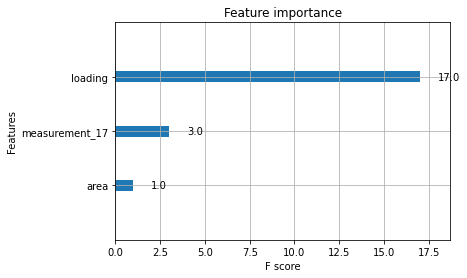

In [86]:
#hide_input
plot_importance(bst)

Once we have an accuracy we are happy with, let's train our model on the entirety of our training dataset. Here, we disregard the validation datasets.

In [88]:
#collapse
bst = train(train_df[features],[],y,[],param,num_round,doVal=False)

In [89]:
#hide
features = [f for f in test_df.columns if f != 'product_code']
preds = predict(test_df[features],bst,to_file=True,ids=ids,sklearn=False,threshold=0.3412498)

[0.33197227 0.33197227 0.33197227 0.33197227 0.40066084]
0.46668547 0.34762716


In [19]:
sub = pd.DataFrame({'id':ids, 'failure':preds})
sub.to_csv('submission.csv', index=False) 

<AxesSubplot:xlabel='product_code', ylabel='loading'>

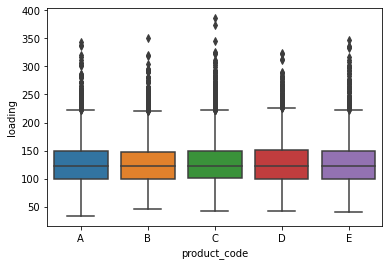

In [125]:
#hide
train_df = pd.read_csv('train.csv') # 26570 rows
test_df = pd.read_csv('test.csv') # 20775 rows

temp = pd.crosstab(index = train_df["attribute_0"],
                   columns = train_df["product_code"])

#sns.heatmap(temp, annot=False)
sns.boxplot(data=train_df, x='product_code', y='loading')